# Ensemble Model for TDE Classification

This notebook combines all trained models into the final submission.

**Steps:**
1. Load OOF and Test predictions from all models
2. Optimize weights using Log Loss minimization
3. Optimize threshold using F1 Score maximization
4. Generate final submission

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import log_loss, precision_recall_curve, f1_score
import warnings

from src.config_loader import get_path, get_seed, get_model_config, get

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
# Configuration from global config.yml
RANDOM_STATE = get_seed()

# Paths from global config.yml
DATA_DIR = get_path('data_processed')
MODEL_DIR = get_path('models')
SUBMISSION_DIR = get_path('submissions')
RAW_DIR = get_path('data_raw')

FOLDS_PATH = DATA_DIR / 'train_folds.csv'
TEST_RAW_PATH = RAW_DIR / 'test_log.csv'

os.makedirs(SUBMISSION_DIR, exist_ok=True)

local_fallback_models = ['xgb', 'lgb', 'cat', 'mlp', 'resnet']

# Attempt to get the list from config.yml
config_models = get('ensemble', {}).get('include_models', [])

if config_models:
    MODEL_NAMES = config_models
    print(f"Using ensemble list from config.yml: {MODEL_NAMES}")
else:
    MODEL_NAMES = local_fallback_models
    print(f"Config list empty or missing. Using local fallback: {MODEL_NAMES}")

Using ensemble list from config.yml: ['xgb', 'lgb', 'cat', 'resnet']


In [3]:
# Load ground truth
print("Loading ground truth and predictions...")
folds_df = pd.read_csv(FOLDS_PATH)
print(f"Folds shape: {folds_df.shape}")

# Load OOF predictions
oof_dfs = {}
for name in MODEL_NAMES:
    path = MODEL_DIR / f'oof_{name}.csv'
    if path.exists():
        oof_dfs[name] = pd.read_csv(path)
        print(f"Loaded OOF {name}: {oof_dfs[name].shape}")
    else:
        print(f"Warning: {path} not found, skipping {name}")

# Load Test predictions
test_dfs = {}
for name in MODEL_NAMES:
    path = MODEL_DIR / f'preds_{name}.csv'
    if path.exists():
        test_dfs[name] = pd.read_csv(path)
        print(f"Loaded Test {name}: {test_dfs[name].shape}")
    else:
        print(f"Warning: {path} not found, skipping {name}")

# Update MODEL_NAMES to only include available models
MODEL_NAMES = [name for name in MODEL_NAMES if name in oof_dfs and name in test_dfs]
print(f"\nAvailable models for ensemble: {MODEL_NAMES}")

Loading ground truth and predictions...
Folds shape: (3043, 3)
Loaded OOF xgb: (3043, 3)
Loaded OOF lgb: (3043, 3)
Loaded OOF cat: (3043, 3)
Loaded OOF resnet: (3043, 3)
Loaded Test xgb: (7135, 2)
Loaded Test lgb: (7135, 2)
Loaded Test cat: (7135, 2)
Loaded Test resnet: (7135, 2)

Available models for ensemble: ['xgb', 'lgb', 'cat', 'resnet']


In [4]:
# Merge OOF predictions on object_id
print("\nMerging OOF predictions...")
oof_merged = folds_df[['object_id', 'target']].copy()

for name in MODEL_NAMES:
    pred_col = f'pred_{name}'
    oof_merged = oof_merged.merge(
        oof_dfs[name][['object_id', pred_col]], 
        on='object_id', 
        how='left'
    )

print(f"Merged OOF shape: {oof_merged.shape}")
print(f"Columns: {oof_merged.columns.tolist()}")

# Merge Test predictions on object_id
print("\nMerging Test predictions...")
test_merged = test_dfs[MODEL_NAMES[0]][['object_id']].copy()

for name in MODEL_NAMES:
    pred_col = f'pred_{name}'
    test_merged = test_merged.merge(
        test_dfs[name][['object_id', pred_col]], 
        on='object_id', 
        how='left'
    )

print(f"Merged Test shape: {test_merged.shape}")
print(f"Columns: {test_merged.columns.tolist()}")


Merging OOF predictions...
Merged OOF shape: (3043, 6)
Columns: ['object_id', 'target', 'pred_xgb', 'pred_lgb', 'pred_cat', 'pred_resnet']

Merging Test predictions...
Merged Test shape: (7135, 5)
Columns: ['object_id', 'pred_xgb', 'pred_lgb', 'pred_cat', 'pred_resnet']


In [5]:
# Prepare arrays for optimization
y_true = oof_merged['target'].values
oof_preds = np.column_stack([oof_merged[f'pred_{name}'].values for name in MODEL_NAMES])
test_preds = np.column_stack([test_merged[f'pred_{name}'].values for name in MODEL_NAMES])

print(f"Target shape: {y_true.shape}")
print(f"OOF predictions shape: {oof_preds.shape}")
print(f"Test predictions shape: {test_preds.shape}")
print(f"\nClass distribution: {np.bincount(y_true.astype(int))}")

Target shape: (3043,)
OOF predictions shape: (3043, 4)
Test predictions shape: (7135, 4)

Class distribution: [2895  148]



=== Model Correlation Analysis ===



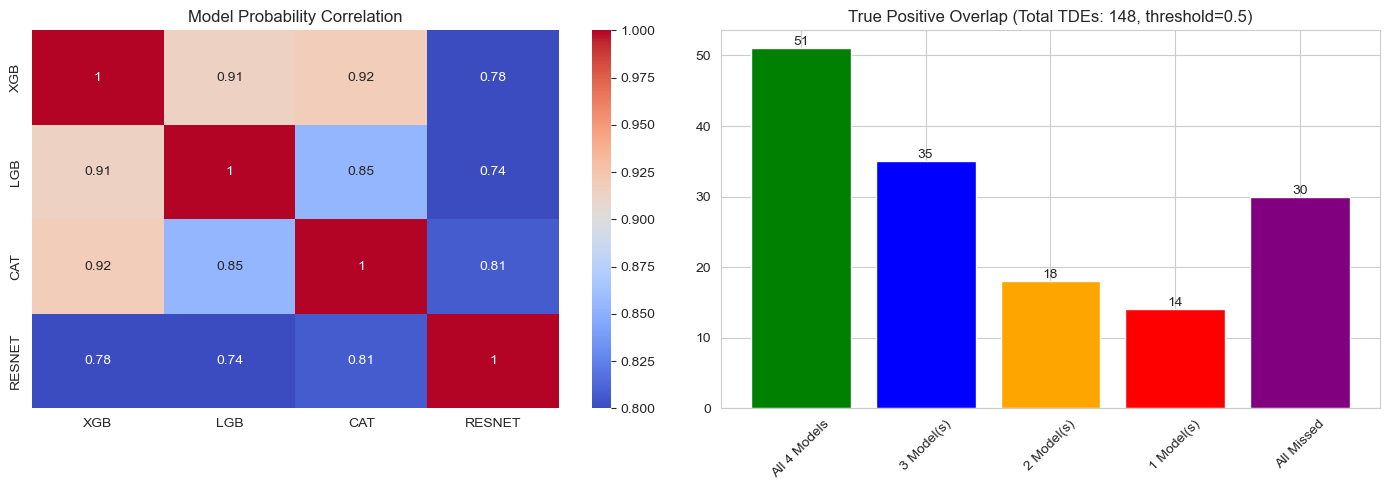

--- Overlap Insights ---
If lower model counts have high values, your models find DIFFERENT TDEs (Ensemble helps a lot).
If 'All N Models' is high, your models are similar (Ensemble will stabilize but boost less).


In [6]:
# Model Correlation Analysis
print("\n=== Model Correlation Analysis ===\n")

# Create probability DataFrame
probs_df = pd.DataFrame({name.upper(): oof_merged[f'pred_{name}'].values for name in MODEL_NAMES})

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Correlation Heatmap (Probability Rank Alignment) ---
sns.heatmap(probs_df.corr(), annot=True, cmap='coolwarm', vmin=0.8, vmax=1.0, ax=axes[0])
axes[0].set_title('Model Probability Correlation')

# --- 2. Binary Overlap (Decision Agreement) ---
temp_threshold = 0.5
binary_df = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= temp_threshold).astype(int) for name in MODEL_NAMES})
binary_df['Sum'] = binary_df.sum(axis=1)
binary_df['Target'] = y_true

# Count overlaps for true positives
n_models = len(MODEL_NAMES)
overlap_counts = []
categories = []
colors = ['green', 'blue', 'orange', 'red', 'purple'][:n_models + 1]

for i in range(n_models, -1, -1):
    count = len(binary_df[(binary_df['Sum'] == i) & (binary_df['Target'] == 1)])
    overlap_counts.append(count)
    if i == n_models:
        categories.append(f'All {n_models} Models')
    elif i == 0:
        categories.append('All Missed')
    else:
        categories.append(f'{i} Model(s)')

bars = axes[1].bar(categories, overlap_counts, color=colors[:len(categories)])
axes[1].set_title(f'True Positive Overlap (Total TDEs: {int(y_true.sum())}, threshold=0.5)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(bars)

plt.tight_layout()
plt.show()

print("--- Overlap Insights ---")
print("If lower model counts have high values, your models find DIFFERENT TDEs (Ensemble helps a lot).")
print("If 'All N Models' is high, your models are similar (Ensemble will stabilize but boost less).")

In [7]:
# Print models in each category for better interpretation
print("\n=== Models in Each Category ===\n")

temp_threshold = 0.5
model_cols = [name.upper() for name in MODEL_NAMES]
binary_analysis_df = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= temp_threshold).astype(int) for name in MODEL_NAMES})
binary_analysis_df['Sum'] = binary_analysis_df[model_cols].sum(axis=1)
binary_analysis_df['Target'] = y_true

n_models = len(MODEL_NAMES)

# For each category (from n_models down to 0)
for i in range(n_models, -1, -1):
    subset = binary_analysis_df[(binary_analysis_df['Sum'] == i) & (binary_analysis_df['Target'] == 1)]
    count = len(subset)
    
    if i == n_models:
        cat_name = f"All {n_models} Models"
    elif i == 0:
        cat_name = "All Missed (0 models)"
    else:
        cat_name = f"Only {i} model(s)"
    
    print(f"--- {cat_name}: {count} TDEs ---")
    
    if count > 0 and i > 0:
        model_detection_counts = {}
        for model_name in model_cols:
            model_detection_counts[model_name] = subset[model_name].sum()
        
        sorted_models = sorted(model_detection_counts.items(), key=lambda x: x[1], reverse=True)
        
        combo_counts = {}
        for idx, row in subset.iterrows():
            detecting_models = tuple(sorted([m for m in model_cols if row[m] == 1]))
            combo_counts[detecting_models] = combo_counts.get(detecting_models, 0) + 1
        
        sorted_combos = sorted(combo_counts.items(), key=lambda x: x[1], reverse=True)
        for combo, combo_count in sorted_combos:
            combo_str = ', '.join(combo) if combo else 'None'
            print(f"  [{combo_str}]: {combo_count} TDEs")
    elif i == 0:
        print(f"  No model detected these {count} TDEs")
    
    print()


=== Models in Each Category ===

--- All 4 Models: 51 TDEs ---
  [CAT, LGB, RESNET, XGB]: 51 TDEs

--- Only 3 model(s): 35 TDEs ---
  [CAT, LGB, XGB]: 21 TDEs
  [CAT, RESNET, XGB]: 8 TDEs
  [CAT, LGB, RESNET]: 6 TDEs

--- Only 2 model(s): 18 TDEs ---
  [CAT, XGB]: 10 TDEs
  [CAT, RESNET]: 4 TDEs
  [CAT, LGB]: 3 TDEs
  [LGB, RESNET]: 1 TDEs

--- Only 1 model(s): 14 TDEs ---
  [CAT]: 11 TDEs
  [XGB]: 2 TDEs
  [RESNET]: 1 TDEs

--- All Missed (0 models): 30 TDEs ---
  No model detected these 30 TDEs



In [8]:
# Optimization Phase 1: Optimize weights to minimize Log Loss
print("\n=== Phase 1: Optimizing Weights (Minimize Log Loss) ===")

def weighted_logloss(weights):
    """Calculate log loss for weighted ensemble."""
    w = np.array(weights)
    w = w / np.sum(w)
    weighted_preds = np.sum(oof_preds * w, axis=1)
    weighted_preds = np.clip(weighted_preds, 1e-7, 1 - 1e-7)
    return log_loss(y_true, weighted_preds)

n_models = len(MODEL_NAMES)
initial_weights = [1.0 / n_models] * n_models

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1) for _ in range(n_models)]

np.random.seed(RANDOM_STATE)
result = minimize(
    weighted_logloss,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-9}
)

optimal_weights = result.x / np.sum(result.x)

print(f"\nOptimization success: {result.success}")
print(f"Final Log Loss: {result.fun:.6f}")
print(f"\nOptimal Weights:")
for name, weight in zip(MODEL_NAMES, optimal_weights):
    print(f"  {name.upper()}: {weight:.4f}")


=== Phase 1: Optimizing Weights (Minimize Log Loss) ===

Optimization success: True
Final Log Loss: 0.082672

Optimal Weights:
  XGB: 0.3533
  LGB: 0.3128
  CAT: 0.3232
  RESNET: 0.0107


In [9]:
# Optimization Phase 2: Optimize threshold to maximize F1 Score
print("\n=== Phase 2: Optimizing Threshold (Maximize F1 Score) ===")

weighted_oof = np.sum(oof_preds * optimal_weights, axis=1)

# Method 1: Using precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, weighted_oof)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_prc = thresholds[best_idx]
best_f1_prc = f1_scores[best_idx]

print(f"\nMethod 1 (Precision-Recall Curve):")
print(f"  Best Threshold: {best_threshold_prc:.4f}")
print(f"  Best F1 Score: {best_f1_prc:.4f}")

# Method 2: Grid search from 0.01 to 0.99
thresholds_grid = np.arange(0.01, 0.99, 0.01)
f1_grid = []

for thresh in thresholds_grid:
    preds_binary = (weighted_oof >= thresh).astype(int)
    f1 = f1_score(y_true, preds_binary)
    f1_grid.append(f1)

best_idx_grid = np.argmax(f1_grid)
best_threshold_grid = thresholds_grid[best_idx_grid]
best_f1_grid = f1_grid[best_idx_grid]

print(f"\nMethod 2 (Grid Search):")
print(f"  Best Threshold: {best_threshold_grid:.4f}")
print(f"  Best F1 Score: {best_f1_grid:.4f}")

if best_f1_prc >= best_f1_grid:
    best_threshold = best_threshold_prc
    best_f1 = best_f1_prc
    print(f"\nUsing Precision-Recall Curve threshold.")
else:
    best_threshold = best_threshold_grid
    best_f1 = best_f1_grid
    print(f"\nUsing Grid Search threshold.")

print(f"\n=== Final Selected Threshold: {best_threshold:.4f} ===")
print(f"=== Final F1 Score (OOF): {best_f1:.4f} ===")


=== Phase 2: Optimizing Threshold (Maximize F1 Score) ===

Method 1 (Precision-Recall Curve):
  Best Threshold: 0.4924
  Best F1 Score: 0.6761



Method 2 (Grid Search):
  Best Threshold: 0.4800
  Best F1 Score: 0.6761

Using Grid Search threshold.

=== Final Selected Threshold: 0.4800 ===
=== Final F1 Score (OOF): 0.6761 ===



=== Binary Overlap with Optimal Threshold ===


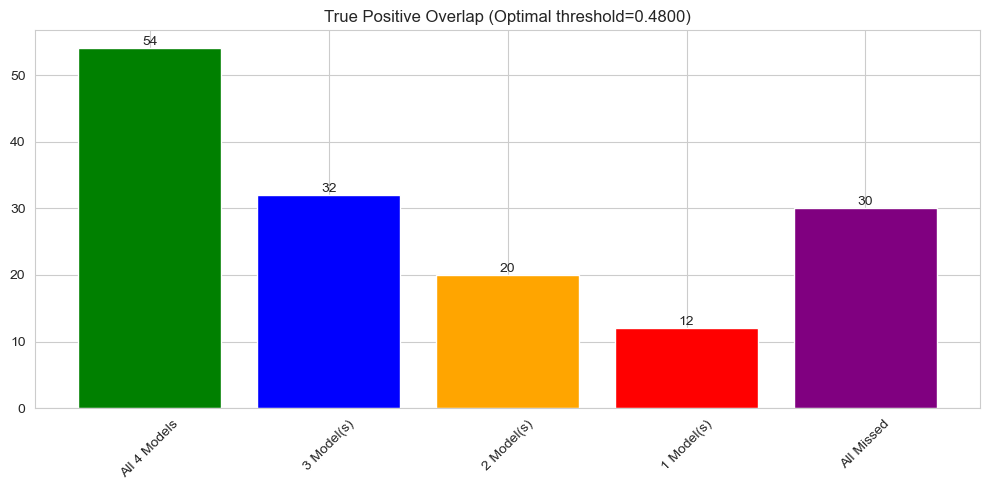

In [10]:
# Visualize overlap with optimal threshold
print("\n=== Binary Overlap with Optimal Threshold ===")

binary_df_opt = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= best_threshold).astype(int) for name in MODEL_NAMES})
binary_df_opt['Sum'] = binary_df_opt.sum(axis=1)
binary_df_opt['Target'] = y_true

n_models = len(MODEL_NAMES)
overlap_counts_opt = []
categories_opt = []
colors_opt = ['green', 'blue', 'orange', 'red', 'purple', 'cyan', 'pink'][:n_models + 1]

for i in range(n_models, -1, -1):
    count = len(binary_df_opt[(binary_df_opt['Sum'] == i) & (binary_df_opt['Target'] == 1)])
    overlap_counts_opt.append(count)
    if i == n_models:
        categories_opt.append(f'All {n_models} Models')
    elif i == 0:
        categories_opt.append('All Missed')
    else:
        categories_opt.append(f'{i} Model(s)')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories_opt, overlap_counts_opt, color=colors_opt[:len(categories_opt)])
ax.set_title(f'True Positive Overlap (Optimal threshold={best_threshold:.4f})')
ax.tick_params(axis='x', rotation=45)
ax.bar_label(bars)
plt.tight_layout()
plt.show()

In [11]:
# Generate Final Submission
print("\n=== Generating Final Submission ===")

weighted_test = np.sum(test_preds * optimal_weights, axis=1)
test_labels = (weighted_test >= best_threshold).astype(int)

submission = pd.DataFrame({
    'object_id': test_merged['object_id'],
    'target': test_labels
})

print(f"Submission shape: {submission.shape}")
print(f"Predicted distribution: {np.bincount(test_labels)}")
print(f"Positive rate: {test_labels.sum() / len(test_labels):.4f}")

submission_path = SUBMISSION_DIR / 'submission_ensemble.csv'
submission.to_csv(submission_path, index=False)
print(f"\nSubmission saved to: {submission_path}")


=== Generating Final Submission ===
Submission shape: (7135, 2)
Predicted distribution: [6814  321]
Positive rate: 0.0450

Submission saved to: D:\MALLORN Private\notebooks\..\submissions\submission_ensemble.csv


In [12]:
# Summary
print("\n" + "="*50)
print(" ENSEMBLE SUMMARY")
print("="*50)
print(f"\nModels used: {MODEL_NAMES}")
print(f"\nOptimal Weights:")
for name, weight in zip(MODEL_NAMES, optimal_weights):
    print(f"  {name.upper()}: {weight:.4f}")
print(f"\nOptimal Threshold: {best_threshold:.4f}")
print(f"OOF F1 Score: {best_f1:.4f}")
print(f"\nTest Predictions:")
print(f"  Total samples: {len(submission)}")
print(f"  Predicted TDEs: {test_labels.sum()}")
print(f"  Positive rate: {test_labels.sum() / len(test_labels):.4f}")
print("="*50)


 ENSEMBLE SUMMARY

Models used: ['xgb', 'lgb', 'cat', 'resnet']

Optimal Weights:
  XGB: 0.3533
  LGB: 0.3128
  CAT: 0.3232
  RESNET: 0.0107

Optimal Threshold: 0.4800
OOF F1 Score: 0.6761

Test Predictions:
  Total samples: 7135
  Predicted TDEs: 321
  Positive rate: 0.0450
